# Unit 1: Root Finding I - The Bisection Method
**Date:** Jan 20 (Tuesday)
**Topic:** Implementing the Bisection Method from scratch.

## 1. The Concept
Finding a root means solving $f(x) = 0$.
The **Bisection Method** is the simplest, most robust numerical method. It relies on the **Intermediate Value Theorem**:
> If a continuous function $f(x)$ changes sign between $a$ and $b$ (i.e., $f(a)$ and $f(b)$ have opposite signs), there must be at least one root between them.

### The Algorithm
1.  Choose an interval $[a, b]$ where $f(a)$ and $f(b)$ have opposite signs.
2.  Calculate the midpoint: $c = \frac{a + b}{2}$.
3.  Evaluate $f(c)$.
4.  Determine which sub-interval ($[a, c]$ or $[c, b]$) contains the root by checking signs again.
5.  Repeat until the interval is tiny (less than our tolerance).

## Problem 1: Visual Inspection (Bracketing)
**Goal:** Before calculating, we must "bracket" the root.
**Task:** Run the code to plot $f(x) = x^3 - 4x - 9$. Visually estimate two integers $a$ and $b$ where the graph crosses zero.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 - 4*x - 9

# Visualization
x = np.linspace(-5, 5, 25)

# print(x)

y = f(x)

print(y)


[-114.          -86.94849537  -64.6712963   -46.734375    -32.7037037
  -22.14525463  -14.625        -9.70891204   -6.96296296   -5.953125
   -6.24537037   -7.4056713    -9.          -10.5943287   -11.75462963
  -12.046875    -11.03703704   -8.29108796   -3.375         4.14525463
   14.7037037    28.734375     46.6712963    68.94849537   96.        ]


/tmp/ipython-input-1057756034.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


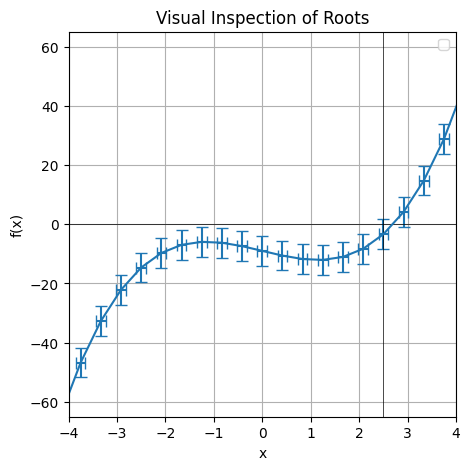

In [ ]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt

yerr_1 = 5*np.ones(shape=y.shape)
xerr_1 = 0.1*np.ones(shape=x.shape)

plt.figure(figsize=(5, 5))
# plt.plot(x, y, color='red', ls='-.', label="f(x) = x^3 - 4x - 9")
# plt.scatter(x, y, marker='^', s=50, label="f(x) = x^3 - 4x - 9")
plt.errorbar(x=x, y=y, xerr=xerr_1, yerr=yerr_1, capsize=4)
plt.axhline(0, color='black', linewidth=0.5) # The x-axis
plt.axvline(2.5, color='black', linewidth=0.5) # The y-axis
plt.grid(True)
plt.xlabel('x')
# yticks = np.arange(10, 60, 10)
plt.ylabel('f(x)')
plt.xlim(-4, 4)
plt.ylim(-65, 65)

# plt.yticks(yticks)
plt.legend()
plt.title("Visual Inspection of Roots")
plt.show()

In [ ]:



# --- STUDENT INPUT ---
# Look at the graph above. Between which two integers does the line cross zero?
bracket_a = 2  # Replace with integer
bracket_b = 3  # Replace with integer

# --- AUTO-GRADER ---
if bracket_a is not ...:
    sign_a = np.sign(f(bracket_a))
    sign_b = np.sign(f(bracket_b))

    print(f"f({bracket_a}) sign: {sign_a}")
    print(f"f({bracket_b}) sign: {sign_b}")

    assert sign_a != sign_b, "Stoppage: Signs are the same! These points do not bracket a root."
    print("✅ Good brackets! The root is trapped between these points.")

f(2) sign: -1
f(3) sign: 1
✅ Good brackets! The root is trapped between these points.


## Problem 2: Implementing the Logic
**Goal:** Complete the core logic of the Bisection algorithm.
**The Logic Trap:** The most common mistake is updating the wrong bound.
* If $f(a)$ and $f(c)$ have **opposite** signs, the root is between $a$ and $c$. So, we move $b$ to $c$.
* Otherwise, the root is between $c$ and $b$. So, we move $a$ to $c$.

In [ ]:
def bisection_solver(func, a, b, tol=1e-6):

    # 1. Sanity Check
    if func(a) * func(b) >= 0:
        print("Error: Initial bounds do not bracket the root.")
        return None

    iteration = 0

    # 2. The Loop
    # We continue as long as the gap (b - a) is bigger than our tolerance
    while (b - a) > tol:
        iteration += 1

        # TODO: Calculate midpoint 'c'
        c = (a + b) / 2.0

        # Check if we accidentally hit the root exactly
        if func(c) == 0:
            break

        # TODO: The Decision Logic (The tricky part)
        # If f(a) and f(c) have OPPOSITE signs (product is negative),
        # the root is in the left half [a, c].
        if func(a) * func(c) < 0:
            # Root is on the left side. Pull 'b' in.
            b = c
        else:
            # Root is on the right side. Pull 'a' in.
            a = c

    print(f"Converged in {iteration} iterations.")
    return c

# --- TEST YOUR SOLVER ---
# We use the function from Problem 1: x^3 - 4x - 9
root = bisection_solver(f, 2, 3, tol=0.0000000000001)

print(f"Calculated Root: {root}")

# # --- AUTO-GRADER ---
# actual_root = 2.706527
# assert root is not None, "Solver returned None. Check your initial brackets."
# assert abs(root - actual_root) < 1e-4, f"Result {root} is inaccurate. Check your update logic (b=c vs a=c)."
# print("✅ Success! You implemented Bisection correctly.")

Converged in 44 iterations.
Calculated Root: 2.7065279544979717


## Problem 3: Tolerance vs. Iterations
**Goal:** Understand the "cost" of precision.

**Question:** How many iterations does it take to find the root of $f(x) = \cos(x) - x$ to high precision?

In [ ]:
def func_transcendental(x):
    return np.cos(x) - x

# plot


# Run the solver with different tolerances
print("--- Low Precision (1e-2) ---")
r1 = bisection_solver(func_transcendental, 0, 1, tol=1e-2)

print("\n--- High Precision (1e-10) ---")
# TODO: Call the solver with a much stricter tolerance
r2 = bisection_solver(func_transcendental, 0, 1, tol=______)

print(f"\nRoot found: {r2}")

# --- AUTO-GRADER ---
assert r2 is not None
assert abs(r2 - 0.739085) < 1e-6, "The root seems wrong."
print("✅ Notice how many more iterations the High Precision run took!")

--- Low Precision (1e-2) ---


NameError: name '______' is not defined